In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO LOW PRICE SEGMENT (<25th percentile)
print("\n🎯 FILTERING TO LOW PRICE SEGMENT (<p25)")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get average price per customer
avg_price = df_quotes.groupby('numero_compte')['mt_apres_remise_ht_devis'].mean().reset_index()
avg_price.columns = ['customer_id', 'avg_price']

# Get 25th percentile
p25 = avg_price['avg_price'].quantile(0.25)

# Filter low price customers
low_price_ids = avg_price[avg_price['avg_price'] <= p25]['customer_id'].tolist()

# Filter data
df_quotes_low_price = df_quotes[df_quotes['numero_compte'].isin(low_price_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Low price customers (<€{p25:.0f}): {len(low_price_ids):,}")
print(f"Quotes: {len(df_quotes_low_price):,}")

# Save to file
df_quotes_low_price.to_csv('cleaned_quote_data_low_price.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_low_price.csv")


🎯 FILTERING TO LOW PRICE SEGMENT (<p25)
Original customers: 25,716
Low price customers (<€4032): 6,429
Quotes: 8,309

✅ Saved to cleaned_quote_data_low_price.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_low_price.csv')


📊 Original quote data: 8,309 quotes from 6,429 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 6,429, Quotes: 8,085
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 6,429 customers | 43.9% converters
⏱️  Execution time: 2.9 seconds
✅ SUCCESS! Achieved ≤ 3s target
CREATING SEQUENCE FEATURES (mode: first_conversion)
  Total quotes: 8,309
  Total customers: 6,429
  Using product column: regroup_famille_equipement_produit_principal
  Window days: 30
  Filtering post-first-purchase data...
    Customers after filter: 6,429
    Quotes after filter: 8,093
⚡ Processing 6,429 customers with sequence features...
  Processed 5,000/6,429 customers

  Adding categorical features...

✅ SEQUENCE FEATURES CREATED
  Total customers: 6,429
  Converters: 2,825 (43.9%)
  Features created: 21
  Product column used: re

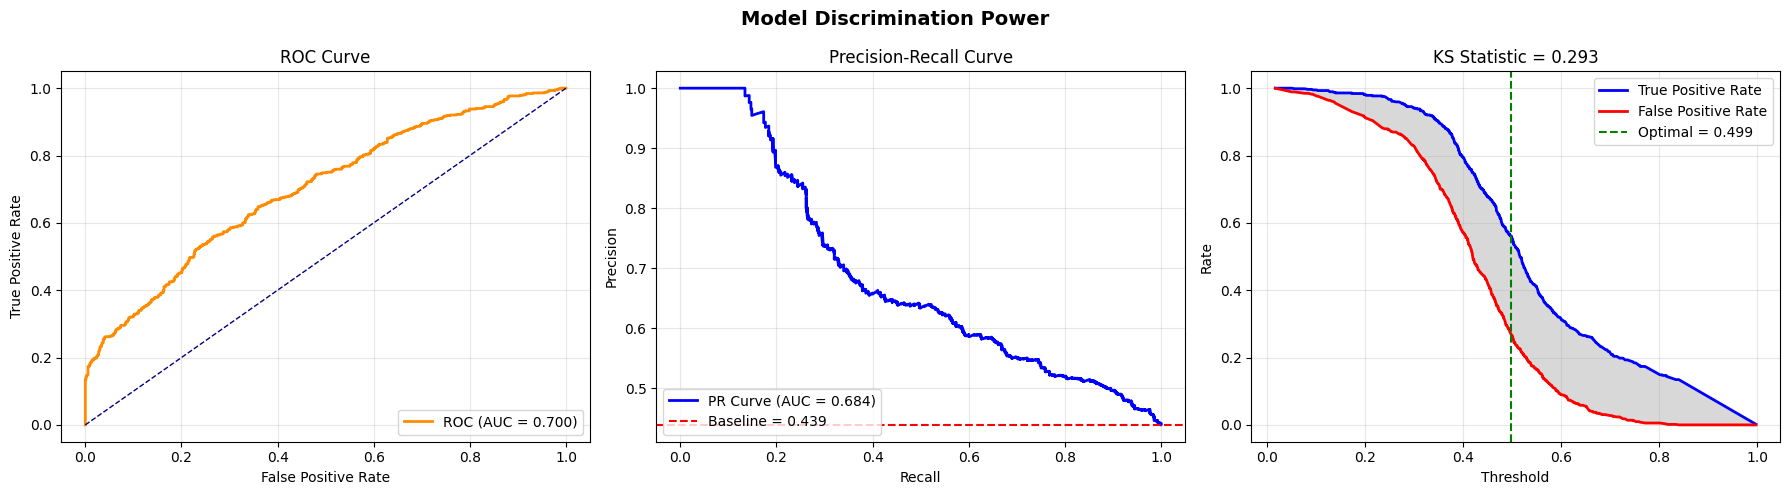

• ROC-AUC: 0.6998
• PR-AUC: 0.6836
• KS Statistic: 0.293 (WEAK discrimination)
• Optimal Threshold: 0.499

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.897
Decile 10 mean prob: 0.178


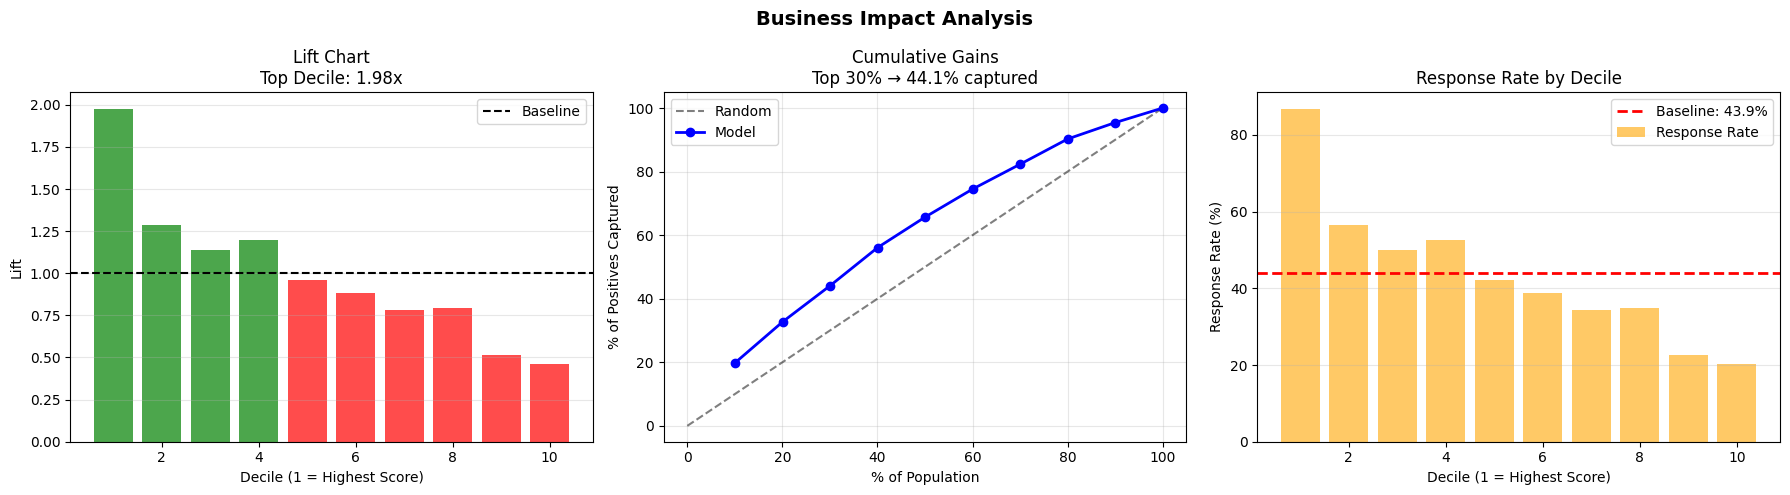

• Top Decile Lift: 0.46x
• Top 30% captures: 44.1% of positives
• Baseline response rate: 43.9%
• Top decile response: 86.8%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


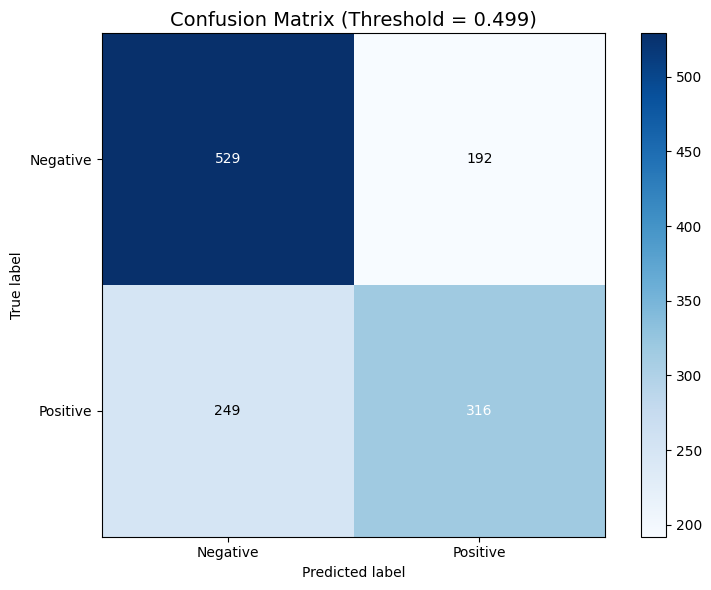

At threshold 0.499:
• Accuracy: 0.657
• Precision: 0.622
• Recall: 0.559
• F1-Score: 0.589
• True Positives: 316
• False Positives: 192
• True Negatives: 529
• False Negatives: 249

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.293 (WEAK discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.46x better than random
   Coverage: Top 30% → 44.1% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.6998 (Excellent if >0.8)
   PR-AUC: 0.6836 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.499
   Precision at threshold: 0.622
   Recall at threshold: 0.559

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                        feature  importance
178     quote_consistency_score    0.078429
180   decision_efficiency_score    0.031811
183        solution_focus_score    0.026027
57             latest_equipment    0.021593
154             engagement_days    0.019333
38          model_variety_score    0.017800
242         price_x_consistency    0.017734
19

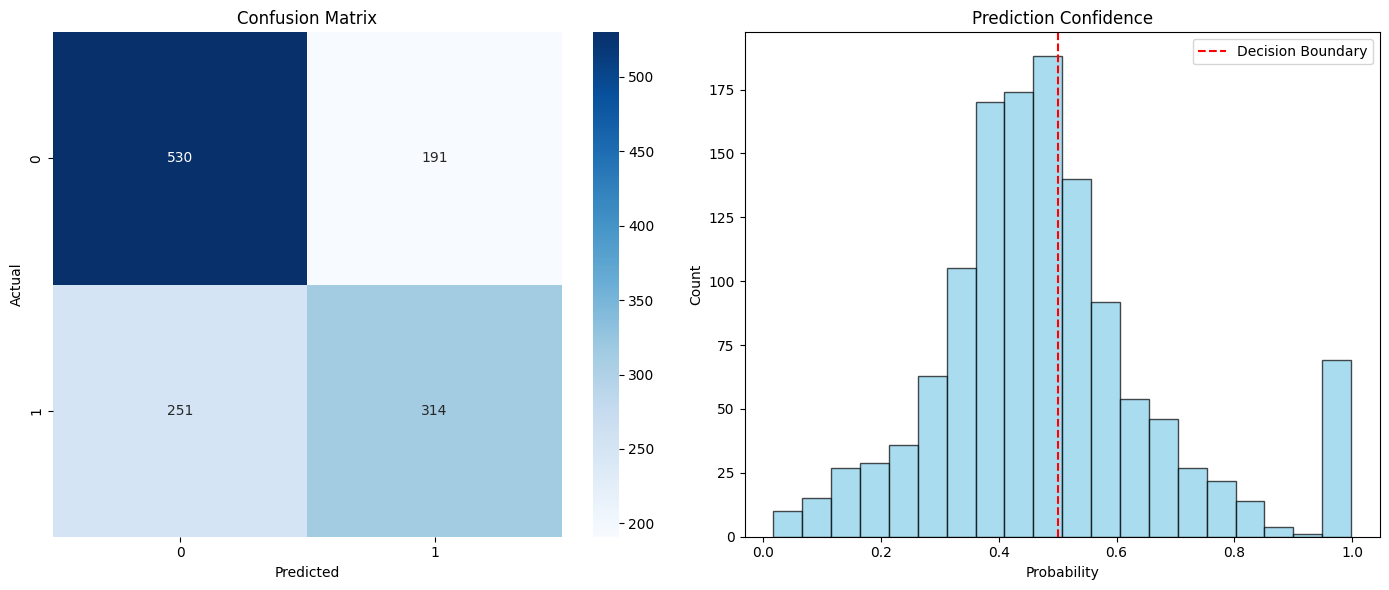

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])